# Compare Baseline ViT and Advanced Model2

This notebook loads:
- Baseline ViT checkpoint from `Zoe3324/flickr30k-baseline`
- Advanced model2 checkpoint from `qasxxsaq/Image-Text-Matching-Model-Advanced`

It supports:
- grouped Recall@1/5/10 comparison
- qualitative image-to-text examples
- qualitative text-to-image examples

In [12]:
!pip install -q datasets transformers huggingface_hub matplotlib pillow tqdm

In [13]:
import random
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from PIL import Image
from transformers import AutoModel, BertModel, BertTokenizer, ViTImageProcessor, ViTModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [14]:
SEED = 42
BASELINE_REPO_ID = "Zoe3324/flickr30k-baseline"
BASELINE_FILENAME = "best_baseline_gelu_freeze_proj256_bs128_lr1e-4_epoch6_ViT_numw4.pt"

ADVANCED_REPO_ID = "qasxxsaq/Image-Text-Matching-Model-Advanced"
ADVANCED_REVISION = "Similarity+Rerank"
ADVANCED_FILENAME = "advanced_model_weights_similarity+rerank.pt"

ADVANCED3_REPO_ID = "Zoe3324/advanced_3"
ADVANCED3_FILENAME = "advanced_model_bs32_e2_lr3e-5_hn5.pt"

DATASET_NAME = "Zoe3324/flickr30k-pairs"
NUM_SAMPLES = 1000
RERANK_TOP_K = 50
KS = (1, 5, 10)
BASELINE_PROJECTION_DIM = 256
BASELINE_TEMPERATURE_INIT = 0.07

random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [15]:
class ProjectionHead(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, output_dim),
            nn.GELU(),
            nn.Linear(output_dim, output_dim),
        )

    def forward(self, x):
        return self.net(x)


class BaselineViTRetrievalModel(nn.Module):
    def __init__(self, projection_dim=BASELINE_PROJECTION_DIM, temperature_init=BASELINE_TEMPERATURE_INIT):
        super().__init__()
        self.image_encoder = ViTModel.from_pretrained("google/vit-base-patch16-224")
        self.text_encoder = AutoModel.from_pretrained("bert-base-uncased")
        self.image_projection = ProjectionHead(768, projection_dim)
        self.text_projection = ProjectionHead(768, projection_dim)
        self.log_temperature = nn.Parameter(torch.log(torch.tensor(1.0 / temperature_init)))

    @torch.no_grad()
    def encode_image(self, pixel_values):
        image_features = self.image_encoder(pixel_values=pixel_values).last_hidden_state[:, 0, :]
        return F.normalize(self.image_projection(image_features), dim=-1)

    @torch.no_grad()
    def encode_text(self, input_ids, attention_mask):
        text_features = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
        return F.normalize(self.text_projection(text_features), dim=-1)


class CrossAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.query = nn.Linear(dim, dim)
        self.key = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)
        self.scale = dim ** -0.5

    def forward(self, q, k, v):
        q_proj = self.query(q)
        k_proj = self.key(k)
        v_proj = self.value(v)
        attn = torch.matmul(q_proj, k_proj.transpose(-2, -1)) * self.scale
        attn = torch.softmax(attn, dim=-1)
        return torch.matmul(attn, v_proj)


class TwoStageModel(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.text_encoder = BertModel.from_pretrained("bert-base-uncased")
        self.image_encoder = ViTModel.from_pretrained("google/vit-base-patch16-224")
        self.image_proj = nn.Linear(768, embed_dim)
        self.text_proj = nn.Linear(768, embed_dim)
        self.cross_attn = CrossAttention(768)
        self.match_head = nn.Sequential(
            nn.Linear(768, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, 1),
        )
        self.temperature = nn.Parameter(torch.tensor(0.07))

    @torch.no_grad()
    def encode_image(self, pixel_values):
        image_tokens = self.image_encoder(pixel_values=pixel_values).last_hidden_state
        image_emb = F.normalize(self.image_proj(image_tokens[:, 0]), dim=-1)
        return image_emb, image_tokens

    @torch.no_grad()
    def encode_text(self, input_ids, attention_mask):
        text_tokens = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        text_emb = F.normalize(self.text_proj(text_tokens[:, 0]), dim=-1)
        return text_emb, text_tokens

    @torch.no_grad()
    def compute_itm(self, text_tokens, image_tokens):
        fused = self.cross_attn(text_tokens, image_tokens, image_tokens)
        fused = fused.mean(dim=1)
        return self.match_head(fused).squeeze(-1)


class HardNegativeCrossAttention(nn.Module):
    def __init__(self, dim, num_heads=8, dropout=0.1, ffn_mult=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * ffn_mult),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * ffn_mult, dim),
            nn.Dropout(dropout),
        )

    def forward(self, q, k, v):
        attn_out, _ = self.attn(q, k, v, need_weights=False)
        x = self.norm1(q + attn_out)
        x = self.norm2(x + self.ffn(x))
        return x


class HardNegativeTwoStageModel(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        self.text_encoder = BertModel.from_pretrained("bert-base-uncased")
        self.image_encoder = ViTModel.from_pretrained("google/vit-base-patch16-224")
        self.image_proj = nn.Linear(768, embed_dim)
        self.text_proj = nn.Linear(768, embed_dim)
        self.cross_attn = HardNegativeCrossAttention(768)
        self.match_head = nn.Sequential(
            nn.Linear(768, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, 1),
        )
        self.temperature = nn.Parameter(torch.tensor(0.07))

    @torch.no_grad()
    def encode_image(self, pixel_values):
        image_tokens = self.image_encoder(pixel_values=pixel_values).last_hidden_state
        image_emb = F.normalize(self.image_proj(image_tokens[:, 0]), dim=-1)
        return image_emb, image_tokens

    @torch.no_grad()
    def encode_text(self, input_ids, attention_mask):
        text_tokens = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        text_emb = F.normalize(self.text_proj(text_tokens[:, 0]), dim=-1)
        return text_emb, text_tokens

    @torch.no_grad()
    def compute_itm(self, text_tokens, image_tokens, attention_mask):
        fused = self.cross_attn(text_tokens, image_tokens, image_tokens)
        token_mask = attention_mask.unsqueeze(-1).float()
        fused = (fused * token_mask).sum(dim=1) / token_mask.sum(dim=1).clamp(min=1.0)
        return self.match_head(fused).squeeze(-1)

In [16]:
dataset = load_dataset(DATASET_NAME)
test_data = dataset["test"]
print(test_data[0])

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x461 at 0x7B4C47D6E420>, 'caption': 'The man with pierced ears is wearing glasses and an orange hat.', 'split': 'test', 'img_id': '25', 'filename': '1007129816.jpg'}


In [17]:
@dataclass
class EvalCache:
    texts: List[str]
    images: List[Image.Image]
    group_ids: List[str]
    filenames: List[str]
    image_embs: torch.Tensor
    text_embs: torch.Tensor


baseline_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
baseline_image_processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
advanced_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
advanced_image_processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
advanced3_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
advanced3_image_processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")

baseline_model = BaselineViTRetrievalModel().to(device)
baseline_ckpt_path = hf_hub_download(repo_id=BASELINE_REPO_ID, filename=BASELINE_FILENAME)
baseline_checkpoint = torch.load(baseline_ckpt_path, map_location=device, weights_only=False)
baseline_model.image_encoder.load_state_dict(baseline_checkpoint["image_encoder"])
baseline_model.text_encoder.load_state_dict(baseline_checkpoint["text_encoder"])
baseline_model.image_projection.load_state_dict(baseline_checkpoint["image_projection"])
baseline_model.text_projection.load_state_dict(baseline_checkpoint["text_projection"])
baseline_model.log_temperature.data = baseline_checkpoint["log_temperature"].to(device)
baseline_model.eval()

advanced_model = TwoStageModel().to(device)
advanced_ckpt_path = hf_hub_download(
    repo_id=ADVANCED_REPO_ID,
    filename=ADVANCED_FILENAME,
    revision=ADVANCED_REVISION,
)
advanced_model.load_state_dict(torch.load(advanced_ckpt_path, map_location=device, weights_only=True))
advanced_model.eval()

advanced3_model = HardNegativeTwoStageModel().to(device)
advanced3_ckpt_path = hf_hub_download(
    repo_id=ADVANCED3_REPO_ID,
    filename=ADVANCED3_FILENAME,
)
advanced3_model.load_state_dict(torch.load(advanced3_ckpt_path, map_location=device, weights_only=True))
advanced3_model.eval()

print("Loaded baseline from", BASELINE_REPO_ID, BASELINE_FILENAME)
print("Loaded advanced from", ADVANCED_REPO_ID, ADVANCED_FILENAME, "@", ADVANCED_REVISION)
print("Loaded advanced_3 from", ADVANCED3_REPO_ID, ADVANCED3_FILENAME)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded baseline from Zoe3324/flickr30k-baseline best_baseline_gelu_freeze_proj256_bs128_lr1e-4_epoch6_ViT_numw4.pt
Loaded advanced from qasxxsaq/Image-Text-Matching-Model-Advanced advanced_model_weights_similarity+rerank.pt @ Similarity+Rerank
Loaded advanced_3 from Zoe3324/advanced_3 advanced_model_bs32_e2_lr3e-5_hn5.pt


In [18]:
def build_subset_records(data, num_samples):
    subset = data.select(range(min(num_samples, len(data)))) if num_samples is not None else data
    texts = [row["caption"] for row in subset]
    images = [row["image"].convert("RGB") for row in subset]
    group_ids = [str(row["img_id"]) for row in subset]
    filenames = [row["filename"] for row in subset]
    return texts, images, group_ids, filenames


@torch.no_grad()
def build_baseline_cache(model, tokenizer, image_processor, data, num_samples=NUM_SAMPLES, batch_size=64):
    texts, images, group_ids, filenames = build_subset_records(data, num_samples)
    image_embs = []
    text_embs = []
    for start in range(0, len(texts), batch_size):
        end = min(start + batch_size, len(texts))
        image_enc = image_processor(images=images[start:end], return_tensors="pt")
        image_embs.append(model.encode_image(image_enc["pixel_values"].to(device)).cpu())
        text_enc = tokenizer(texts[start:end], padding="max_length", truncation=True, max_length=64, return_tensors="pt")
        text_embs.append(model.encode_text(text_enc["input_ids"].to(device), text_enc["attention_mask"].to(device)).cpu())
    return EvalCache(texts, images, group_ids, filenames, torch.cat(image_embs), torch.cat(text_embs))


@torch.no_grad()
def build_advanced_cache(model, tokenizer, image_processor, data, num_samples=NUM_SAMPLES, batch_size=64):
    texts, images, group_ids, filenames = build_subset_records(data, num_samples)
    image_embs = []
    text_embs = []
    for start in range(0, len(texts), batch_size):
        end = min(start + batch_size, len(texts))
        image_enc = image_processor(images=images[start:end], return_tensors="pt")
        image_embs.append(model.encode_image(image_enc["pixel_values"].to(device))[0].cpu())
        text_enc = tokenizer(texts[start:end], padding="max_length", truncation=True, max_length=32, return_tensors="pt")
        text_embs.append(model.encode_text(text_enc["input_ids"].to(device), text_enc["attention_mask"].to(device))[0].cpu())
    return EvalCache(texts, images, group_ids, filenames, torch.cat(image_embs), torch.cat(text_embs))


def grouped_recall_at_k(score_matrix, query_group_ids, target_group_ids, ks=KS):
    group_to_indices = {}
    for idx, gid in enumerate(target_group_ids):
        group_to_indices.setdefault(gid, []).append(idx)
    metrics = {}
    for k in ks:
        total_recall = 0.0
        for i, gid in enumerate(query_group_ids):
            topk = set(score_matrix[i].topk(k).indices.tolist())
            correct_set = set(group_to_indices[gid])
            total_recall += len(topk & correct_set) / len(correct_set)
        metrics[f"r@{k}"] = total_recall / len(query_group_ids)
    return metrics


@torch.no_grad()
def build_advanced_rerank_scores_i2t(model, cache, tokenizer, image_processor, top_k=RERANK_TOP_K):
    coarse_sim = cache.image_embs @ cache.text_embs.T
    n = coarse_sim.size(0)
    score_matrix = torch.full((n, n), -1.0)
    for i in range(n):
        candidates = coarse_sim[i].topk(top_k).indices.tolist()
        image_enc = image_processor(images=[cache.images[i]] * len(candidates), return_tensors="pt")
        text_enc = tokenizer([cache.texts[j] for j in candidates], padding="max_length", truncation=True, max_length=32, return_tensors="pt")
        itm_logits = model.compute_itm(
            model.encode_text(text_enc["input_ids"].to(device), text_enc["attention_mask"].to(device))[1],
            model.encode_image(image_enc["pixel_values"].to(device))[1],
        )
        itm_scores = torch.sigmoid(itm_logits).cpu()
        for rank, j in enumerate(candidates):
            score_matrix[i, j] = itm_scores[rank]
    return score_matrix


@torch.no_grad()
def build_advanced_rerank_scores_t2i(model, cache, tokenizer, image_processor, top_k=RERANK_TOP_K):
    coarse_sim = cache.text_embs @ cache.image_embs.T
    n = coarse_sim.size(0)
    score_matrix = torch.full((n, n), -1.0)
    for i in range(n):
        candidates = coarse_sim[i].topk(top_k).indices.tolist()
        text_enc = tokenizer([cache.texts[i]] * len(candidates), padding="max_length", truncation=True, max_length=32, return_tensors="pt")
        image_enc = image_processor(images=[cache.images[j] for j in candidates], return_tensors="pt")
        itm_logits = model.compute_itm(
            model.encode_text(text_enc["input_ids"].to(device), text_enc["attention_mask"].to(device))[1],
            model.encode_image(image_enc["pixel_values"].to(device))[1],
        )
        itm_scores = torch.sigmoid(itm_logits).cpu()
        for rank, j in enumerate(candidates):
            score_matrix[i, j] = itm_scores[rank]
    return score_matrix


@torch.no_grad()
def build_advanced3_rerank_scores_i2t(model, cache, tokenizer, image_processor, top_k=RERANK_TOP_K):
    coarse_sim = cache.image_embs @ cache.text_embs.T
    n = coarse_sim.size(0)
    score_matrix = torch.full((n, n), -1.0)
    for i in range(n):
        candidates = coarse_sim[i].topk(top_k).indices.tolist()
        image_enc = image_processor(images=[cache.images[i]] * len(candidates), return_tensors="pt")
        text_enc = tokenizer([cache.texts[j] for j in candidates], padding="max_length", truncation=True, max_length=32, return_tensors="pt")
        itm_logits = model.compute_itm(
            model.encode_text(text_enc["input_ids"].to(device), text_enc["attention_mask"].to(device))[1],
            model.encode_image(image_enc["pixel_values"].to(device))[1],
            text_enc["attention_mask"].to(device),
        )
        itm_scores = torch.sigmoid(itm_logits).cpu()
        for rank, j in enumerate(candidates):
            score_matrix[i, j] = itm_scores[rank]
    return score_matrix


@torch.no_grad()
def build_advanced3_rerank_scores_t2i(model, cache, tokenizer, image_processor, top_k=RERANK_TOP_K):
    coarse_sim = cache.text_embs @ cache.image_embs.T
    n = coarse_sim.size(0)
    score_matrix = torch.full((n, n), -1.0)
    for i in range(n):
        candidates = coarse_sim[i].topk(top_k).indices.tolist()
        text_enc = tokenizer([cache.texts[i]] * len(candidates), padding="max_length", truncation=True, max_length=32, return_tensors="pt")
        image_enc = image_processor(images=[cache.images[j] for j in candidates], return_tensors="pt")
        itm_logits = model.compute_itm(
            model.encode_text(text_enc["input_ids"].to(device), text_enc["attention_mask"].to(device))[1],
            model.encode_image(image_enc["pixel_values"].to(device))[1],
            text_enc["attention_mask"].to(device),
        )
        itm_scores = torch.sigmoid(itm_logits).cpu()
        for rank, j in enumerate(candidates):
            score_matrix[i, j] = itm_scores[rank]
    return score_matrix


In [19]:
baseline_cache = build_baseline_cache(baseline_model, baseline_tokenizer, baseline_image_processor, test_data, num_samples=NUM_SAMPLES)
advanced_cache = build_advanced_cache(advanced_model, advanced_tokenizer, advanced_image_processor, test_data, num_samples=NUM_SAMPLES)
advanced3_cache = build_advanced_cache(advanced3_model, advanced3_tokenizer, advanced3_image_processor, test_data, num_samples=NUM_SAMPLES)

baseline_i2t_scores = baseline_cache.image_embs @ baseline_cache.text_embs.T
baseline_t2i_scores = baseline_cache.text_embs @ baseline_cache.image_embs.T
advanced_coarse_i2t_scores = advanced_cache.image_embs @ advanced_cache.text_embs.T
advanced_coarse_t2i_scores = advanced_cache.text_embs @ advanced_cache.image_embs.T
advanced_rerank_i2t_scores = build_advanced_rerank_scores_i2t(advanced_model, advanced_cache, advanced_tokenizer, advanced_image_processor, top_k=RERANK_TOP_K)
advanced_rerank_t2i_scores = build_advanced_rerank_scores_t2i(advanced_model, advanced_cache, advanced_tokenizer, advanced_image_processor, top_k=RERANK_TOP_K)
advanced3_coarse_i2t_scores = advanced3_cache.image_embs @ advanced3_cache.text_embs.T
advanced3_coarse_t2i_scores = advanced3_cache.text_embs @ advanced3_cache.image_embs.T
advanced3_rerank_i2t_scores = build_advanced3_rerank_scores_i2t(advanced3_model, advanced3_cache, advanced3_tokenizer, advanced3_image_processor, top_k=RERANK_TOP_K)
advanced3_rerank_t2i_scores = build_advanced3_rerank_scores_t2i(advanced3_model, advanced3_cache, advanced3_tokenizer, advanced3_image_processor, top_k=RERANK_TOP_K)

baseline_i2t = grouped_recall_at_k(baseline_i2t_scores, baseline_cache.group_ids, baseline_cache.group_ids)
baseline_t2i = grouped_recall_at_k(baseline_t2i_scores, baseline_cache.group_ids, baseline_cache.group_ids)
advanced_coarse_i2t = grouped_recall_at_k(advanced_coarse_i2t_scores, advanced_cache.group_ids, advanced_cache.group_ids)
advanced_coarse_t2i = grouped_recall_at_k(advanced_coarse_t2i_scores, advanced_cache.group_ids, advanced_cache.group_ids)
advanced_rerank_i2t = grouped_recall_at_k(advanced_rerank_i2t_scores, advanced_cache.group_ids, advanced_cache.group_ids)
advanced_rerank_t2i = grouped_recall_at_k(advanced_rerank_t2i_scores, advanced_cache.group_ids, advanced_cache.group_ids)
advanced3_coarse_i2t = grouped_recall_at_k(advanced3_coarse_i2t_scores, advanced3_cache.group_ids, advanced3_cache.group_ids)
advanced3_coarse_t2i = grouped_recall_at_k(advanced3_coarse_t2i_scores, advanced3_cache.group_ids, advanced3_cache.group_ids)
advanced3_rerank_i2t = grouped_recall_at_k(advanced3_rerank_i2t_scores, advanced3_cache.group_ids, advanced3_cache.group_ids)
advanced3_rerank_t2i = grouped_recall_at_k(advanced3_rerank_t2i_scores, advanced3_cache.group_ids, advanced3_cache.group_ids)

print("=== Baseline ViT ===")
for k in KS:
    print(f"i2t R@{k}: {baseline_i2t[f'r@{k}']:.4f} | t2i R@{k}: {baseline_t2i[f'r@{k}']:.4f}")

print("\n=== Advanced Model2 Coarse ===")
for k in KS:
    print(f"i2t R@{k}: {advanced_coarse_i2t[f'r@{k}']:.4f} | t2i R@{k}: {advanced_coarse_t2i[f'r@{k}']:.4f}")

print("\n=== Advanced Model2 Re-rank ===")
for k in KS:
    print(f"i2t R@{k}: {advanced_rerank_i2t[f'r@{k}']:.4f} | t2i R@{k}: {advanced_rerank_t2i[f'r@{k}']:.4f}")

print("\n=== Advanced_3 Coarse ===")
for k in KS:
    print(f"i2t R@{k}: {advanced3_coarse_i2t[f'r@{k}']:.4f} | t2i R@{k}: {advanced3_coarse_t2i[f'r@{k}']:.4f}")

print("\n=== Advanced_3 Re-rank ===")
for k in KS:
    print(f"i2t R@{k}: {advanced3_rerank_i2t[f'r@{k}']:.4f} | t2i R@{k}: {advanced3_rerank_t2i[f'r@{k}']:.4f}")

=== Baseline ViT ===
i2t R@1: 0.1370 | t2i R@1: 0.1064
i2t R@5: 0.5020 | t2i R@5: 0.5320
i2t R@10: 0.6740 | t2i R@10: 0.6860

=== Advanced Model2 Coarse ===
i2t R@1: 0.1560 | t2i R@1: 0.1304
i2t R@5: 0.6440 | t2i R@5: 0.6520
i2t R@10: 0.7980 | t2i R@10: 0.8230

=== Advanced Model2 Re-rank ===
i2t R@1: 0.1320 | t2i R@1: 0.1072
i2t R@5: 0.5490 | t2i R@5: 0.5360
i2t R@10: 0.7540 | t2i R@10: 0.7260

=== Advanced_3 Coarse ===
i2t R@1: 0.1620 | t2i R@1: 0.1412
i2t R@5: 0.6550 | t2i R@5: 0.7060
i2t R@10: 0.8290 | t2i R@10: 0.8340

=== Advanced_3 Re-rank ===
i2t R@1: 0.1520 | t2i R@1: 0.1382
i2t R@5: 0.6400 | t2i R@5: 0.6910
i2t R@10: 0.8060 | t2i R@10: 0.8120


In [22]:
def topk_texts_from_scores(score_row, texts, top_k):
    indices = score_row.topk(top_k).indices.tolist()
    return [(idx, float(score_row[idx]), texts[idx]) for idx in indices]


def topk_images_from_scores(score_row, filenames, top_k):
    indices = score_row.topk(top_k).indices.tolist()
    return [(idx, float(score_row[idx]), filenames[idx]) for idx in indices]


@torch.no_grad()
def qualitative_image_query(query_idx=0, top_k=5, rerank_top_k=RERANK_TOP_K):
    print(f"Query image index: {query_idx}")
    print(f"Ground-truth filename: {baseline_cache.filenames[query_idx]}")
    gt_group = baseline_cache.group_ids[query_idx]
    print("Ground-truth captions:")
    for idx, text in enumerate(baseline_cache.texts):
        if baseline_cache.group_ids[idx] == gt_group:
            print(" -", text)

    plt.figure(figsize=(4, 4))
    plt.imshow(baseline_cache.images[query_idx])
    plt.axis("off")
    plt.title("Query image")
    plt.show()

    print("Baseline top captions:")
    for rank, (_, score, text) in enumerate(topk_texts_from_scores(baseline_i2t_scores[query_idx], baseline_cache.texts, top_k), start=1):
        print(f"{rank}. [{score:.4f}] {text}")

    print("\nAdvanced coarse top captions:")
    for rank, (_, score, text) in enumerate(topk_texts_from_scores(advanced_coarse_i2t_scores[query_idx], advanced_cache.texts, top_k), start=1):
        print(f"{rank}. [{score:.4f}] {text}")

    candidates = advanced_coarse_i2t_scores[query_idx].topk(rerank_top_k).indices.tolist()
    image_enc = advanced_image_processor(images=[advanced_cache.images[query_idx]] * len(candidates), return_tensors="pt")
    text_enc = advanced_tokenizer([advanced_cache.texts[j] for j in candidates], padding="max_length", truncation=True, max_length=32, return_tensors="pt")
    itm_logits = advanced_model.compute_itm(
        advanced_model.encode_text(text_enc["input_ids"].to(device), text_enc["attention_mask"].to(device))[1],
        advanced_model.encode_image(image_enc["pixel_values"].to(device))[1],
    )
    itm_scores = torch.sigmoid(itm_logits).cpu()
    reranked = sorted(
        [(candidates[i], float(itm_scores[i]), advanced_cache.texts[candidates[i]]) for i in range(len(candidates))],
        key=lambda x: x[1], reverse=True,
    )[:top_k]
    print("\nAdvanced rerank top captions:")
    for rank, (_, score, text) in enumerate(reranked, start=1):
        print(f"{rank}. [{score:.4f}] {text}")

    print("\nAdvanced_3 coarse top captions:")
    for rank, (_, score, text) in enumerate(topk_texts_from_scores(advanced3_coarse_i2t_scores[query_idx], advanced3_cache.texts, top_k), start=1):
        print(f"{rank}. [{score:.4f}] {text}")

    candidates = advanced3_coarse_i2t_scores[query_idx].topk(rerank_top_k).indices.tolist()
    image_enc = advanced3_image_processor(images=[advanced3_cache.images[query_idx]] * len(candidates), return_tensors="pt")
    text_enc = advanced3_tokenizer([advanced3_cache.texts[j] for j in candidates], padding="max_length", truncation=True, max_length=32, return_tensors="pt")
    itm_logits = advanced3_model.compute_itm(
        advanced3_model.encode_text(text_enc["input_ids"].to(device), text_enc["attention_mask"].to(device))[1],
        advanced3_model.encode_image(image_enc["pixel_values"].to(device))[1],
        text_enc["attention_mask"].to(device),
    )
    itm_scores = torch.sigmoid(itm_logits).cpu()
    reranked = sorted(
        [(candidates[i], float(itm_scores[i]), advanced3_cache.texts[candidates[i]]) for i in range(len(candidates))],
        key=lambda x: x[1], reverse=True,
    )[:top_k]
    print("\nAdvanced_3 rerank top captions:")
    for rank, (_, score, text) in enumerate(reranked, start=1):
        print(f"{rank}. [{score:.4f}] {text}")


@torch.no_grad()
def qualitative_text_query(query_idx=0, top_k=3, rerank_top_k=RERANK_TOP_K):
    query_text = baseline_cache.texts[query_idx]
    print(f"Query caption index: {query_idx}")
    print(f"Query caption: {query_text}")
    print(f"Ground-truth filename: {baseline_cache.filenames[query_idx]}")

    print("\nBaseline top images:")
    baseline_top = topk_images_from_scores(baseline_t2i_scores[query_idx], baseline_cache.filenames, top_k)
    for rank, (_, score, filename) in enumerate(baseline_top, start=1):
        print(f"{rank}. [{score:.4f}] {filename}")

    fig, axes = plt.subplots(1, top_k, figsize=(4 * top_k, 4))
    for ax, (idx, score, filename) in zip(axes, baseline_top):
        ax.imshow(baseline_cache.images[idx])
        ax.axis("off")
        ax.set_title(f"Baseline\n{filename}\n{score:.4f}")
    plt.tight_layout()
    plt.show()

    print("Advanced coarse top images:")
    advanced_top = topk_images_from_scores(advanced_coarse_t2i_scores[query_idx], advanced_cache.filenames, top_k)
    for rank, (_, score, filename) in enumerate(advanced_top, start=1):
        print(f"{rank}. [{score:.4f}] {filename}")

    fig, axes = plt.subplots(1, top_k, figsize=(4 * top_k, 4))
    for ax, (idx, score, filename) in zip(axes, advanced_top):
        ax.imshow(advanced_cache.images[idx])
        ax.axis("off")
        ax.set_title(f"Adv coarse\n{filename}\n{score:.4f}")
    plt.tight_layout()
    plt.show()

    candidates = advanced_coarse_t2i_scores[query_idx].topk(rerank_top_k).indices.tolist()
    text_enc = advanced_tokenizer([advanced_cache.texts[query_idx]] * len(candidates), padding="max_length", truncation=True, max_length=32, return_tensors="pt")
    image_enc = advanced_image_processor(images=[advanced_cache.images[j] for j in candidates], return_tensors="pt")
    itm_logits = advanced_model.compute_itm(
        advanced_model.encode_text(text_enc["input_ids"].to(device), text_enc["attention_mask"].to(device))[1],
        advanced_model.encode_image(image_enc["pixel_values"].to(device))[1],
    )
    itm_scores = torch.sigmoid(itm_logits).cpu()
    reranked = sorted(
        [(candidates[i], float(itm_scores[i]), advanced_cache.filenames[candidates[i]]) for i in range(len(candidates))],
        key=lambda x: x[1], reverse=True,
    )[:top_k]
    print("Advanced rerank top images:")
    for rank, (_, score, filename) in enumerate(reranked, start=1):
        print(f"{rank}. [{score:.4f}] {filename}")

    fig, axes = plt.subplots(1, top_k, figsize=(4 * top_k, 4))
    for ax, (idx, score, filename) in zip(axes, reranked):
        ax.imshow(advanced_cache.images[idx])
        ax.axis("off")
        ax.set_title(f"Adv rerank\n{filename}\n{score:.4f}")
    plt.tight_layout()
    plt.show()

    print("Advanced_3 coarse top images:")
    advanced3_top = topk_images_from_scores(advanced3_coarse_t2i_scores[query_idx], advanced3_cache.filenames, top_k)
    for rank, (_, score, filename) in enumerate(advanced3_top, start=1):
        print(f"{rank}. [{score:.4f}] {filename}")

    fig, axes = plt.subplots(1, top_k, figsize=(4 * top_k, 4))
    for ax, (idx, score, filename) in zip(axes, advanced3_top):
        ax.imshow(advanced3_cache.images[idx])
        ax.axis("off")
        ax.set_title(f"Adv3 coarse\n{filename}\n{score:.4f}")
    plt.tight_layout()
    plt.show()

    candidates = advanced3_coarse_t2i_scores[query_idx].topk(rerank_top_k).indices.tolist()
    text_enc = advanced3_tokenizer([advanced3_cache.texts[query_idx]] * len(candidates), padding="max_length", truncation=True, max_length=32, return_tensors="pt")
    image_enc = advanced3_image_processor(images=[advanced3_cache.images[j] for j in candidates], return_tensors="pt")
    itm_logits = advanced3_model.compute_itm(
        advanced3_model.encode_text(text_enc["input_ids"].to(device), text_enc["attention_mask"].to(device))[1],
        advanced3_model.encode_image(image_enc["pixel_values"].to(device))[1],
        text_enc["attention_mask"].to(device),
    )
    itm_scores = torch.sigmoid(itm_logits).cpu()
    reranked = sorted(
        [(candidates[i], float(itm_scores[i]), advanced3_cache.filenames[candidates[i]]) for i in range(len(candidates))],
        key=lambda x: x[1], reverse=True,
    )[:top_k]
    print("Advanced_3 rerank top images:")
    for rank, (_, score, filename) in enumerate(reranked, start=1):
        print(f"{rank}. [{score:.4f}] {filename}")

    fig, axes = plt.subplots(1, top_k, figsize=(4 * top_k, 4))
    for ax, (idx, score, filename) in zip(axes, reranked):
        ax.imshow(advanced3_cache.images[idx])
        ax.axis("off")
        ax.set_title(f"Adv3 rerank\n{filename}\n{score:.4f}")
    plt.tight_layout()
    plt.show()

Query image index: 25
Ground-truth filename: 1039637574.jpg
Ground-truth captions:
 - A bride in a light pink dress poses for a picture with male relatives and is being photographed by a man in a cream shirt with white pants.
 - A man in light colored clothing photographs a group of men wearing dark suits and hats standing around a woman dressed in a strapless gown.
 - A photographer takes a picture of a group of one girl in a pink dress and 10 boys in suits and hats.
 - A man photographs a woman in a pink dress and a throng of men in suits.
 - Man taking a photograph of a well dressed group of teens.


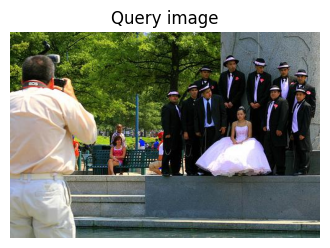

Baseline top captions:
1. [0.4614] A bride in a light pink dress poses for a picture with male relatives and is being photographed by a man in a cream shirt with white pants.
2. [0.4558] A woman is holding a small white statue.
3. [0.4412] A Chinese + man and younger boy in some type of worship place worshiping.
4. [0.4240] A blond woman holding a white statue.
5. [0.4071] A man photographs a woman in a pink dress and a throng of men in suits.

Advanced coarse top captions:
1. [0.5595] A bride in a light pink dress poses for a picture with male relatives and is being photographed by a man in a cream shirt with white pants.
2. [0.4964] A man photographs a woman in a pink dress and a throng of men in suits.
3. [0.4910] A man in light colored clothing photographs a group of men wearing dark suits and hats standing around a woman dressed in a strapless gown.
4. [0.4250] A large group of people stand outside of a church.
5. [0.4183] A group of people standing on the lawn in front of a build

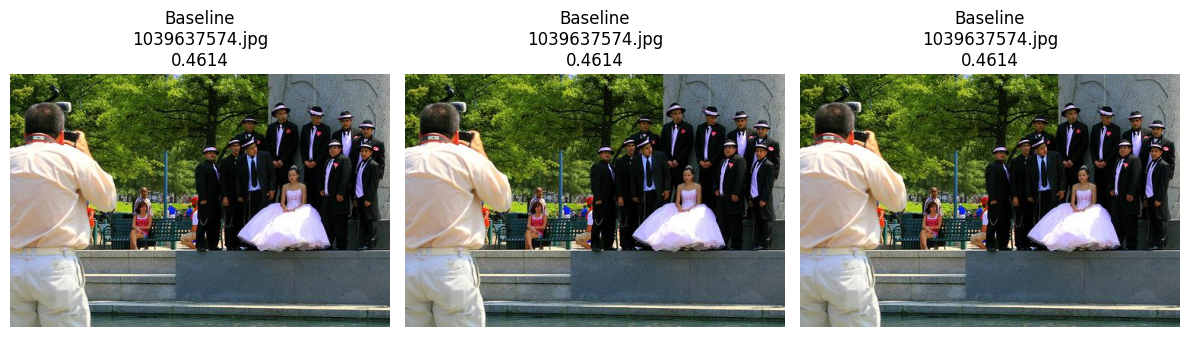

Advanced coarse top images:
1. [0.5595] 1039637574.jpg
2. [0.5595] 1039637574.jpg
3. [0.5595] 1039637574.jpg


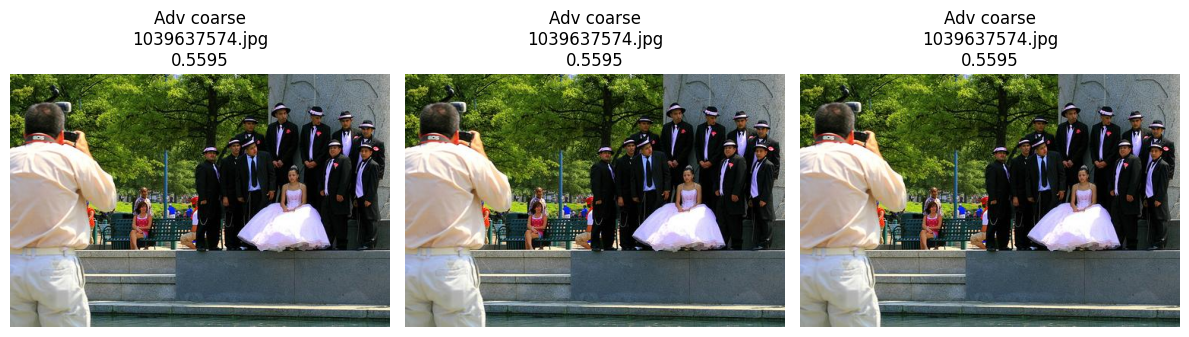

Advanced rerank top images:
1. [0.9913] 1039637574.jpg
2. [0.9913] 1039637574.jpg
3. [0.9913] 1039637574.jpg


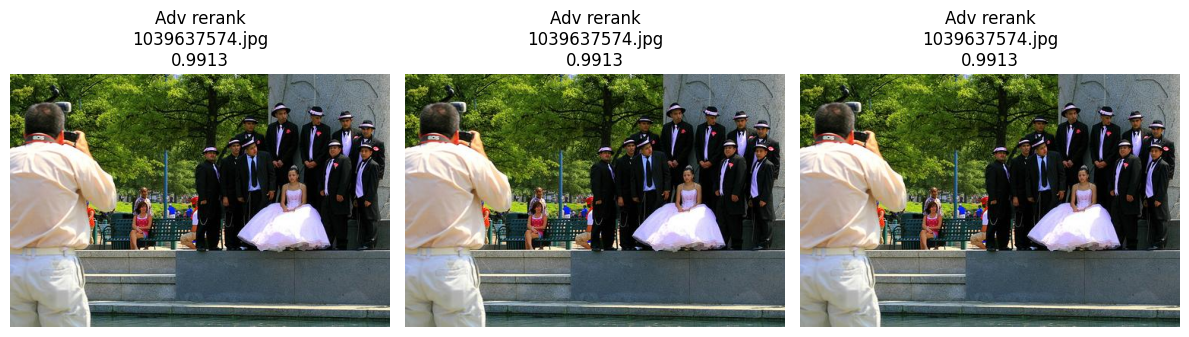

Advanced_3 coarse top images:
1. [0.5961] 1039637574.jpg
2. [0.5961] 1039637574.jpg
3. [0.5961] 1039637574.jpg


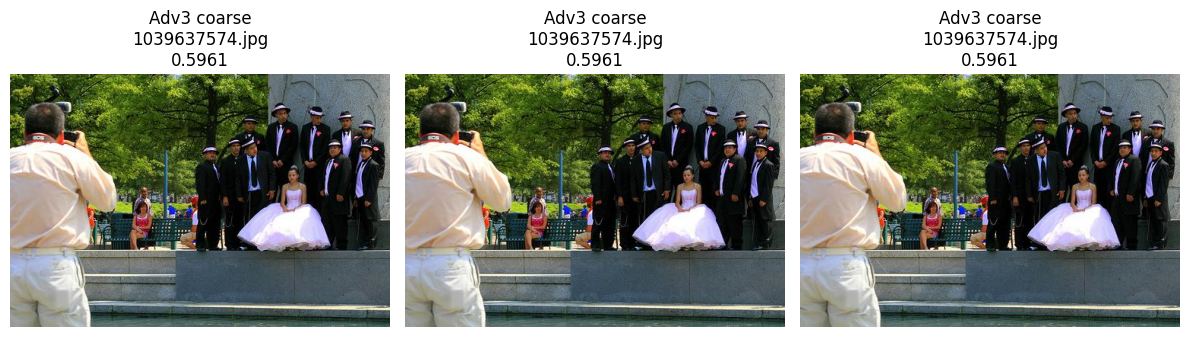

Advanced_3 rerank top images:
1. [0.9881] 1039637574.jpg
2. [0.9881] 1039637574.jpg
3. [0.9881] 1039637574.jpg


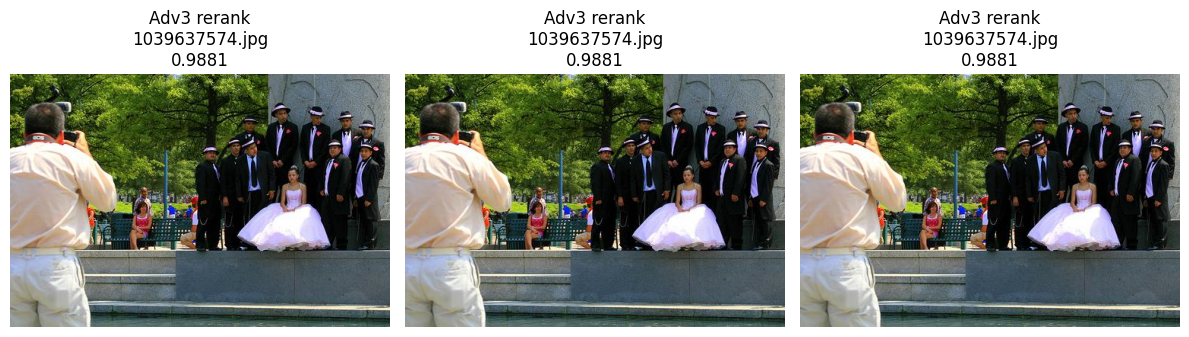

In [28]:
# Change query_idx to the example you want.
qualitative_image_query(query_idx=25, top_k=5, rerank_top_k=RERANK_TOP_K)
qualitative_text_query(query_idx=25, top_k=3, rerank_top_k=RERANK_TOP_K)